In [1]:
import numpy as np
import time
import pickle
import pandas as pd
import re
import matplotlib.pyplot as plt
import torch
import os
import pickle
import pandas as pd
from pathlib import Path
import re

In [2]:
class RandomRightAngleRotation:
    """Randomly rotate PIL image by 90, 180, or 270 degrees."""
    def __call__(self, x):
        angle = int(torch.randint(1, 4, ()).item()) * 90
        return x.rotate(angle)

# BloodMNIST

In [3]:
blood_perf = {}

# eqCLR
for frac in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]:
    knns = []

    for rs in range(3):
        eval_path = f'results_img33_crops/bloodmnist/sample_efficiency/model_eval/001-seed{rs}_bloodmnist33-eqCLR_N4_SE_nested_droplast_frac{str(frac)}_eval.pkl'
        # details_path = f'results_img33_crops/bloodmnist/sample_efficiency/model_details/001-seed{rs}_blood_mnist33-eqCLR_N4_SE_frac{str(frac)}_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        knns.append(eval['euclidean'][10])

    blood_perf[f'eqCLR frac {str(frac)}'] = {}
    blood_perf[f'eqCLR frac {str(frac)}']['KNN'] = np.mean(knns)
    blood_perf[f'eqCLR frac {str(frac)}']['KNN_std'] = np.std(knns)

# SimCLR
for frac in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]:
    knns = []

    for rs in range(3):
        eval_path = f'results_img33_crops/bloodmnist/sample_efficiency/model_eval/101-seed_{rs}-bloodmnist28-Resnet18_SE_nested_droplast_frac{str(frac)}_eval.pkl'
        # details_path = f'results_img33_crops/bloodmnist/sample_efficiency/model_details/001-seed{rs}_blood_mnist33-eqCLR_N4_SE_frac{str(frac)}_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        knns.append(eval['euclidean'][10])

    blood_perf[f'SimCLR frac {str(frac)}'] = {}
    blood_perf[f'SimCLR frac {str(frac)}']['KNN'] = np.mean(knns)
    blood_perf[f'SimCLR frac {str(frac)}']['KNN_std'] = np.std(knns)

blood_perf_df = pd.DataFrame(blood_perf).T
display(blood_perf_df)

,KNN,KNN_std
eqCLR frac 0.01,0.572250,0.020533
eqCLR frac 0.05,0.602455,0.038281
eqCLR frac 0.1,0.696775,0.023748
eqCLR frac 0.2,0.726980,0.013644
eqCLR frac 0.3,0.775309,0.021135
eqCLR frac 0.4,0.787489,0.008271
eqCLR frac 0.5,0.791289,0.009609
eqCLR frac 0.75,0.846439,0.004775
eqCLR frac 1.0,0.868849,0.006334
SimCLR frac 0.01,0.526259,0.027836


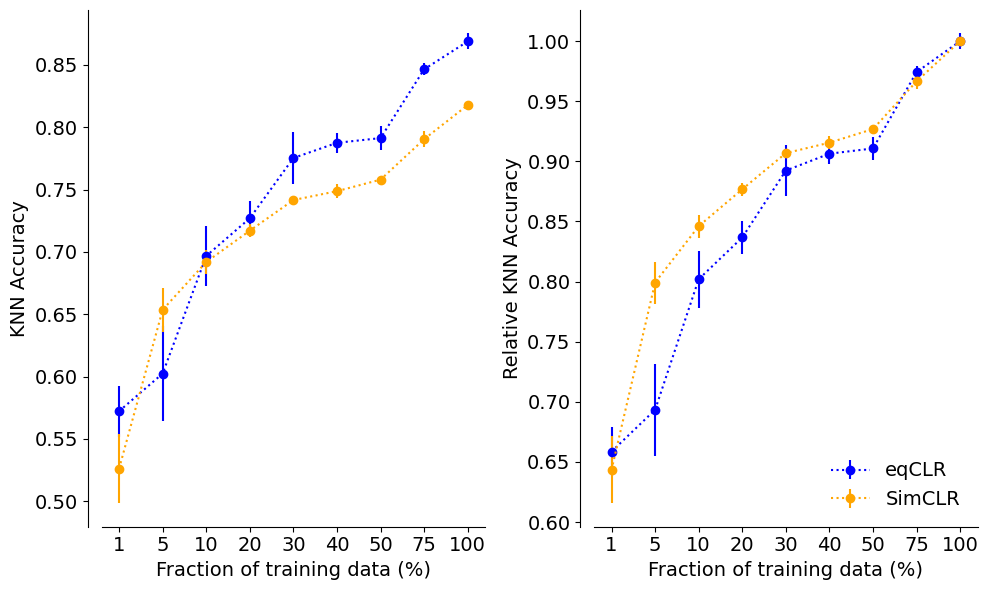

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10,6))
size = 14

x_labels = ['1', '5', '10', '20', '30', '40', '50', '75', '100']
fractions = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]

x = range(len(fractions))

# eqCLR
eqclr_means = [blood_perf[f'eqCLR frac {frac}']['KNN'] for frac in fractions]
eqclr_stds  = [blood_perf[f'eqCLR frac {frac}']['KNN_std'] for frac in fractions]

# SimCLR
simclr_means = [blood_perf[f'SimCLR frac {frac}']['KNN'] for frac in fractions]
simclr_stds  = [blood_perf[f'SimCLR frac {frac}']['KNN_std'] for frac in fractions]

# Plot
ax[0].errorbar(
    x,
    eqclr_means,
    yerr=eqclr_stds,
    fmt='o',
    linestyle=':',
    color='blue',
    label='eqCLR'
)

ax[0].errorbar(
    x,
    simclr_means,
    yerr=simclr_stds,
    fmt='o',
    linestyle=':',
    color='orange',
    label='SimCLR'
)

ax[0].set_xticks(x)
ax[0].set_xticklabels(x_labels)

ax[0].set_xlabel('Fraction of training data (%)', fontsize=size)
ax[0].set_ylabel('KNN Accuracy', fontsize=size)

# relative performance
# Plot
ax[1].errorbar(
    x,
    eqclr_means / max(eqclr_means),
    yerr=eqclr_stds,
    fmt='o',
    linestyle=':',
    color='blue',
    label='eqCLR'
)

ax[1].errorbar(
    x,
    simclr_means / max(simclr_means),
    yerr=simclr_stds,
    fmt='o',
    linestyle=':',
    color='orange',
    label='SimCLR'
)

ax[1].set_xticks(x)
ax[1].set_xticklabels(x_labels)
ax[1].set_xlabel('Fraction of training data (%)', fontsize=size)
ax[1].set_ylabel('Relative KNN Accuracy', fontsize=size)
ax[1].legend(frameon=False, loc='lower right', fontsize=size)


for i in range(2):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['left'].set_position(('outward', 10))
    ax[i].tick_params(axis='both', which='major', labelsize=size)

plt.tight_layout()

# DermaMNIST (33)

In [5]:
derma_perf = {}

# eqCLR
for frac in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]:
    knns = []

    for rs in range(3):
        eval_path = f'results_img33_crops/dermamnist/sample_efficiency/model_eval/001-seed{rs}_dermamnist33-eqCLR_N4_SE_nested_frac{str(frac)}_eval.pkl'
        # details_path = f'results_img33_crops/dermamnist/sample_efficiency/model_details/001-seed{rs}_dermamnist33-eqCLR_N4_SE_frac{str(frac)}_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        knns.append(eval['euclidean'][10])

    derma_perf[f'eqCLR frac {str(frac)}'] = {}
    derma_perf[f'eqCLR frac {str(frac)}']['KNN'] = np.mean(knns)
    derma_perf[f'eqCLR frac {str(frac)}']['KNN_std'] = np.std(knns)

# SimCLR
for frac in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]:
    knns = []

    for rs in range(3):
        eval_path = f'results_img33_crops/dermamnist/sample_efficiency/model_eval/001-seed_{rs}-dermamnist28-Resnet18_SE_nested_droplast_frac{str(frac)}_eval.pkl'
        # details_path = f'results_img33_crops/dermamnist/sample_efficiency/model_details/001-seed{rs}_dermamnist33-eqCLR_N4_SE_frac{str(frac)}_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        knns.append(eval['euclidean'][10])

    derma_perf[f'SimCLR frac {str(frac)}'] = {}
    derma_perf[f'SimCLR frac {str(frac)}']['KNN'] = np.mean(knns)
    derma_perf[f'SimCLR frac {str(frac)}']['KNN_std'] = np.std(knns)

derma_perf_df = pd.DataFrame(derma_perf).T
display(derma_perf_df)

,KNN,KNN_std
eqCLR frac 0.01,0.662510,0.001924
eqCLR frac 0.05,0.659019,0.004926
eqCLR frac 0.1,0.664007,0.012260
eqCLR frac 0.2,0.681297,0.007135
eqCLR frac 0.3,0.688612,0.006633
eqCLR frac 0.4,0.696592,0.003784
eqCLR frac 0.5,0.688113,0.008004
eqCLR frac 0.75,0.705071,0.004824
eqCLR frac 1.0,0.708396,0.003002
SimCLR frac 0.01,0.660017,0.011549


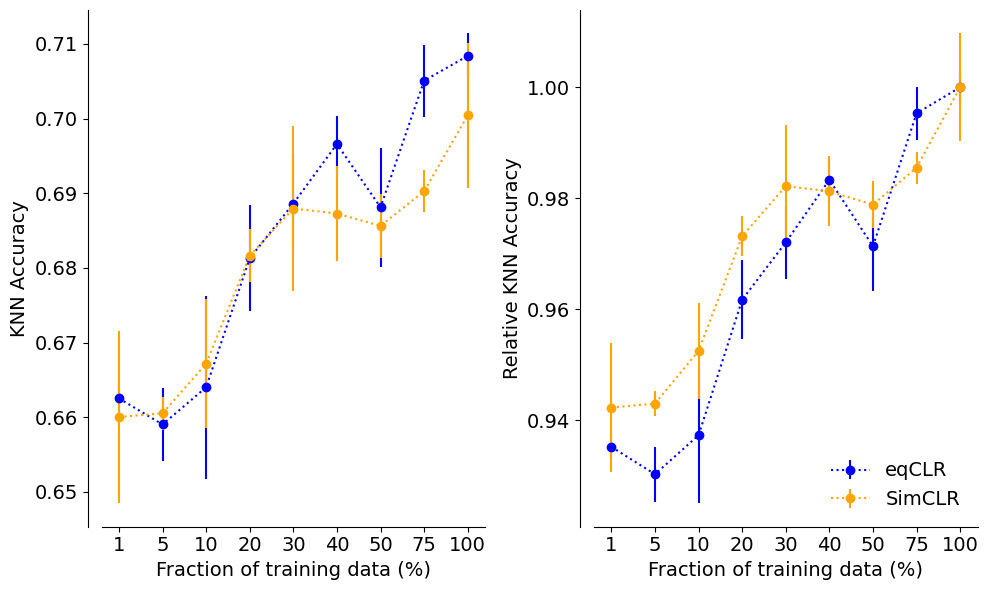

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10,6))
size = 14

x_labels = ['1', '5', '10', '20', '30', '40', '50', '75', '100']
fractions = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]

x = range(len(fractions))

# eqCLR
eqclr_means = [derma_perf[f'eqCLR frac {frac}']['KNN'] for frac in fractions]
eqclr_stds  = [derma_perf[f'eqCLR frac {frac}']['KNN_std'] for frac in fractions]

# SimCLR
simclr_means = [derma_perf[f'SimCLR frac {frac}']['KNN'] for frac in fractions]
simclr_stds  = [derma_perf[f'SimCLR frac {frac}']['KNN_std'] for frac in fractions]

# Plot
ax[0].errorbar(
    x,
    eqclr_means,
    yerr=eqclr_stds,
    fmt='o',
    linestyle=':',
    color='blue',
    label='eqCLR'
)

ax[0].errorbar(
    x,
    simclr_means,
    yerr=simclr_stds,
    fmt='o',
    linestyle=':',
    color='orange',
    label='SimCLR'
)

ax[0].set_xticks(x)
ax[0].set_xticklabels(x_labels)

ax[0].set_xlabel('Fraction of training data (%)', fontsize=size)
ax[0].set_ylabel('KNN Accuracy', fontsize=size)

# relative performance
# Plot
ax[1].errorbar(
    x,
    eqclr_means / max(eqclr_means),
    yerr=eqclr_stds,
    fmt='o',
    linestyle=':',
    color='blue',
    label='eqCLR'
)

ax[1].errorbar(
    x,
    simclr_means / max(simclr_means),
    yerr=simclr_stds,
    fmt='o',
    linestyle=':',
    color='orange',
    label='SimCLR'
)

ax[1].set_xticks(x)
ax[1].set_xticklabels(x_labels)
ax[1].set_xlabel('Fraction of training data (%)', fontsize=size)
ax[1].set_ylabel('Relative KNN Accuracy', fontsize=size)
ax[1].legend(frameon=False, loc='lower right', fontsize=size)


for i in range(2):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['left'].set_position(('outward', 10))
    ax[i].tick_params(axis='both', which='major', labelsize=size)

plt.tight_layout()

# PathMNIST

In [7]:
path_perf = {}

# eqCLR
for frac in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]:
    knns = []

    for rs in range(3):
        eval_path = f'results_img33_crops/pathmnist/sample_efficiency/model_eval/001-seed{rs}_pathmnist33-eqCLR_N4_SE_nested_droplast_frac{str(frac)}_eval.pkl'
        # details_path = f'results_img33_crops/dermamnist/sample_efficiency/model_details/001-seed{rs}_dermamnist33-eqCLR_N4_SE_frac{str(frac)}_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        knns.append(eval['euclidean'][10])

    path_perf[f'eqCLR frac {str(frac)}'] = {}
    path_perf[f'eqCLR frac {str(frac)}']['KNN'] = np.mean(knns)
    path_perf[f'eqCLR frac {str(frac)}']['KNN_std'] = np.std(knns)

# SimCLR
for frac in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]:
    knns = []

    for rs in range(3):
        eval_path = f'results_img33_crops/pathmnist/sample_efficiency/model_eval/101-seed_{rs}-pathmnist28-Resnet18_SE_nested_droplast_frac{str(frac)}_eval.pkl'
        # details_path = f'results_img33_crops/dermamnist/sample_efficiency/model_details/001-seed{rs}_dermamnist33-eqCLR_N4_SE_frac{str(frac)}_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        knns.append(eval['euclidean'][10])

    path_perf[f'SimCLR frac {str(frac)}'] = {}
    path_perf[f'SimCLR frac {str(frac)}']['KNN'] = np.mean(knns)
    path_perf[f'SimCLR frac {str(frac)}']['KNN_std'] = np.std(knns)

path_perf_df = pd.DataFrame(path_perf).T
display(path_perf_df)

,KNN,KNN_std
eqCLR frac 0.01,0.506267,0.017453
eqCLR frac 0.05,0.693083,0.009033
eqCLR frac 0.1,0.813695,0.007326
eqCLR frac 0.2,0.862163,0.004331
eqCLR frac 0.3,0.870891,0.004671
eqCLR frac 0.4,0.877205,0.001104
eqCLR frac 0.5,0.880919,0.002601
eqCLR frac 0.75,0.890947,0.001530
eqCLR frac 1.0,0.895265,0.001973
SimCLR frac 0.01,0.491922,0.033241


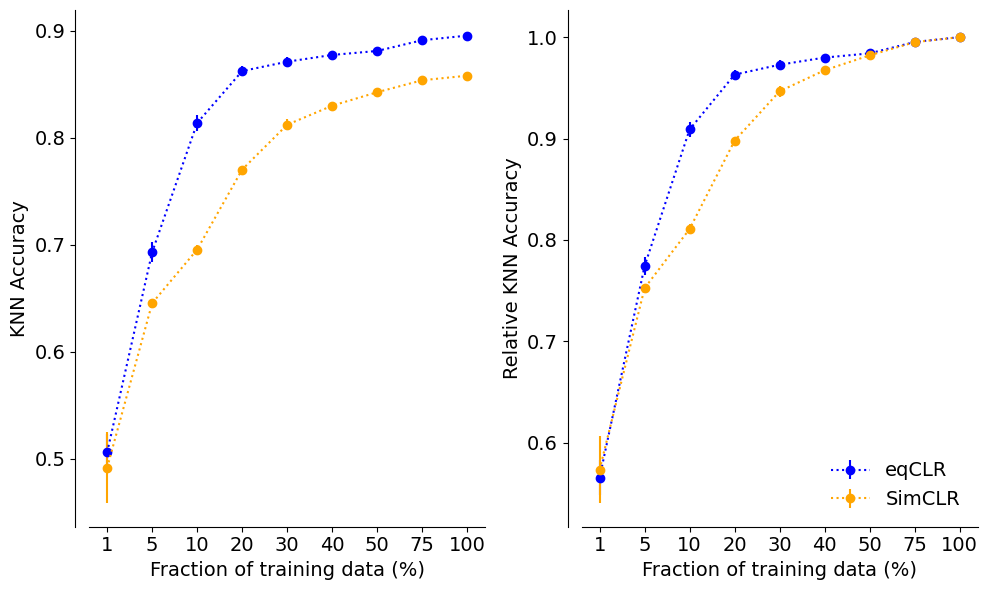

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10,6))
size = 14

x_labels = ['1', '5', '10', '20', '30', '40', '50', '75', '100']
fractions = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]

x = range(len(fractions))

# eqCLR
eqclr_means = [path_perf[f'eqCLR frac {frac}']['KNN'] for frac in fractions]
eqclr_stds  = [path_perf[f'eqCLR frac {frac}']['KNN_std'] for frac in fractions]

# SimCLR
simclr_means = [path_perf[f'SimCLR frac {frac}']['KNN'] for frac in fractions]
simclr_stds  = [path_perf[f'SimCLR frac {frac}']['KNN_std'] for frac in fractions]

# Plot
ax[0].errorbar(
    x,
    eqclr_means,
    yerr=eqclr_stds,
    fmt='o',
    linestyle=':',
    color='blue',
    label='eqCLR'
)

ax[0].errorbar(
    x,
    simclr_means,
    yerr=simclr_stds,
    fmt='o',
    linestyle=':',
    color='orange',
    label='SimCLR'
)

ax[0].set_xticks(x)
ax[0].set_xticklabels(x_labels)

ax[0].set_xlabel('Fraction of training data (%)', fontsize=size)
ax[0].set_ylabel('KNN Accuracy', fontsize=size)

# relative performance
# Plot
ax[1].errorbar(
    x,
    eqclr_means / max(eqclr_means),
    yerr=eqclr_stds,
    fmt='o',
    linestyle=':',
    color='blue',
    label='eqCLR'
)

ax[1].errorbar(
    x,
    simclr_means / max(simclr_means),
    yerr=simclr_stds,
    fmt='o',
    linestyle=':',
    color='orange',
    label='SimCLR'
)

ax[1].set_xticks(x)
ax[1].set_xticklabels(x_labels)
ax[1].set_xlabel('Fraction of training data (%)', fontsize=size)
ax[1].set_ylabel('Relative KNN Accuracy', fontsize=size)
ax[1].legend(frameon=False, loc='lower right', fontsize=size)


for i in range(2):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['left'].set_position(('outward', 10))
    ax[i].tick_params(axis='both', which='major', labelsize=size)

plt.tight_layout()

# Cifar10

In [9]:
cifar_perf = {}

# eqCLR
for frac in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]:
    knns = []

    for rs in range(3):
        eval_path = f'results_img33_crops/cifar10/sample_efficiency/model_eval/001-seed{rs}_cifar33-eqCLR_N2_flip_SE_nested_droplast_frac{str(frac)}_eval.pkl'
        # details_path = f'results_img33_crops/dermamnist/sample_efficiency/model_details/001-seed{rs}_dermamnist33-eqCLR_N4_SE_frac{str(frac)}_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        knns.append(eval['euclidean'][10])

    cifar_perf[f'eqCLR frac {str(frac)}'] = {}
    cifar_perf[f'eqCLR frac {str(frac)}']['KNN'] = np.mean(knns)
    cifar_perf[f'eqCLR frac {str(frac)}']['KNN_std'] = np.std(knns)

# SimCLR
for frac in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]:
    knns = []

    for rs in range(3):
        eval_path = f'results_img33_crops/cifar10/sample_efficiency/model_eval/101-seed_{rs}-cifar10-Resnet18_SE_nested_droplast_frac{str(frac)}_eval.pkl'
        # details_path = f'results_img33_crops/dermamnist/sample_efficiency/model_details/001-seed{rs}_dermamnist33-eqCLR_N4_SE_frac{str(frac)}_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        knns.append(eval['euclidean'][10])

    cifar_perf[f'SimCLR frac {str(frac)}'] = {}
    cifar_perf[f'SimCLR frac {str(frac)}']['KNN'] = np.mean(knns)
    cifar_perf[f'SimCLR frac {str(frac)}']['KNN_std'] = np.std(knns)

cifar_perf_df = pd.DataFrame(cifar_perf).T
display(cifar_perf_df)

,KNN,KNN_std
eqCLR frac 0.01,0.269333,0.002762
eqCLR frac 0.05,0.363533,0.006931
eqCLR frac 0.1,0.447833,0.002384
eqCLR frac 0.2,0.544167,0.001126
eqCLR frac 0.3,0.603167,0.004213
eqCLR frac 0.4,0.647167,0.004705
eqCLR frac 0.5,0.685467,0.003430
eqCLR frac 0.75,0.735967,0.000262
eqCLR frac 1.0,0.765767,0.001470
SimCLR frac 0.01,0.267467,0.003229


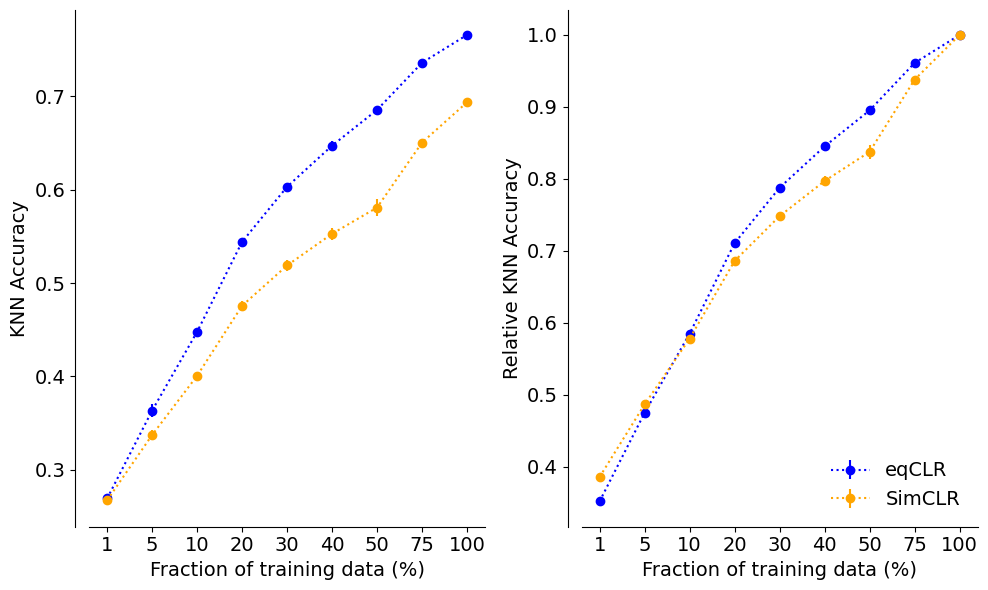

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10,6))
size = 14

x_labels = ['1', '5', '10', '20', '30', '40', '50', '75', '100']
fractions = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]

x = range(len(fractions))

# eqCLR
eqclr_means = [cifar_perf[f'eqCLR frac {frac}']['KNN'] for frac in fractions]
eqclr_stds  = [cifar_perf[f'eqCLR frac {frac}']['KNN_std'] for frac in fractions]

# SimCLR
simclr_means = [cifar_perf[f'SimCLR frac {frac}']['KNN'] for frac in fractions]
simclr_stds  = [cifar_perf[f'SimCLR frac {frac}']['KNN_std'] for frac in fractions]

# Plot
ax[0].errorbar(
    x,
    eqclr_means,
    yerr=eqclr_stds,
    fmt='o',
    linestyle=':',
    color='blue',
    label='eqCLR'
)

ax[0].errorbar(
    x,
    simclr_means,
    yerr=simclr_stds,
    fmt='o',
    linestyle=':',
    color='orange',
    label='SimCLR'
)

ax[0].set_xticks(x)
ax[0].set_xticklabels(x_labels)

ax[0].set_xlabel('Fraction of training data (%)', fontsize=size)
ax[0].set_ylabel('KNN Accuracy', fontsize=size)

# relative performance
# Plot
ax[1].errorbar(
    x,
    eqclr_means / max(eqclr_means),
    yerr=eqclr_stds,
    fmt='o',
    linestyle=':',
    color='blue',
    label='eqCLR'
)

ax[1].errorbar(
    x,
    simclr_means / max(simclr_means),
    yerr=simclr_stds,
    fmt='o',
    linestyle=':',
    color='orange',
    label='SimCLR'
)

ax[1].set_xticks(x)
ax[1].set_xticklabels(x_labels)
ax[1].set_xlabel('Fraction of training data (%)', fontsize=size)
ax[1].set_ylabel('Relative KNN Accuracy', fontsize=size)
ax[1].legend(frameon=False, loc='lower right', fontsize=size)


for i in range(2):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['left'].set_position(('outward', 10))
    ax[i].tick_params(axis='both', which='major', labelsize=size)

plt.tight_layout()

# Combined

In [11]:
x_labels = ['1', '10', '20', '30', '50', '75', '100']
fractions = [0.01, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]

# eqCLR
eqclr_means = [
    [blood_perf[f'eqCLR frac {frac}']['KNN'] for frac in fractions],
    [path_perf[f'eqCLR frac {frac}']['KNN'] for frac in fractions],
    [derma_perf[f'eqCLR frac {frac}']['KNN'] for frac in fractions],
    [cifar_perf[f'eqCLR frac {frac}']['KNN'] for frac in fractions]
]
eqclr_stds  = [
    [blood_perf[f'eqCLR frac {frac}']['KNN_std'] for frac in fractions],
    [path_perf[f'eqCLR frac {frac}']['KNN_std'] for frac in fractions],
    [derma_perf[f'eqCLR frac {frac}']['KNN_std'] for frac in fractions],
    [cifar_perf[f'eqCLR frac {frac}']['KNN_std'] for frac in fractions]
]

# SimCLR
simclr_means = [
    [blood_perf[f'SimCLR frac {frac}']['KNN'] for frac in fractions],
    [path_perf[f'SimCLR frac {frac}']['KNN'] for frac in fractions],
    [derma_perf[f'SimCLR frac {frac}']['KNN'] for frac in fractions],
    [cifar_perf[f'SimCLR frac {frac}']['KNN'] for frac in fractions]
]
simclr_stds  = [
    [blood_perf[f'SimCLR frac {frac}']['KNN_std'] for frac in fractions],
    [path_perf[f'SimCLR frac {frac}']['KNN_std'] for frac in fractions],
    [derma_perf[f'SimCLR frac {frac}']['KNN_std'] for frac in fractions],
    [cifar_perf[f'SimCLR frac {frac}']['KNN_std'] for frac in fractions]
]

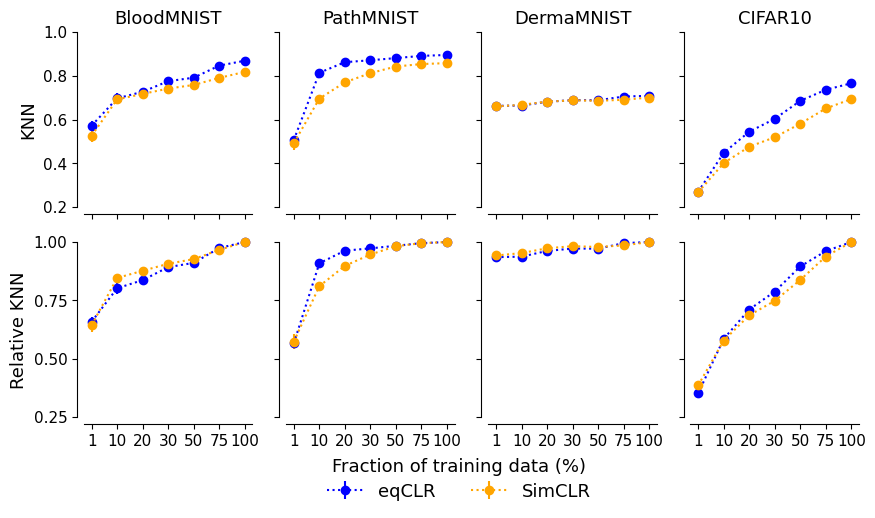

In [18]:
fig, ax = plt.subplots(2, 4, figsize=(10,5), sharex=True, sharey='row')

fontsize = 13

dataset_names = ['BloodMNIST', 'PathMNIST', 'DermaMNIST', 'CIFAR10']

for i, name in enumerate(dataset_names):
    # Plot eqCLR
    ax[0, i].errorbar(
        x=range(len(fractions)),
        y=eqclr_means[i],
        yerr=eqclr_stds[i],
        fmt='o',
        linestyle=':',
        color='blue',
        label='eqCLR',
        clip_on=False
    )

    # Plot SimCLR
    ax[0, i].errorbar(
        x=range(len(fractions)),
        y=simclr_means[i],
        yerr=simclr_stds[i],
        fmt='o',
        linestyle=':',
        color='orange',
        label='SimCLR',
        clip_on=False
    )

    ax[0, i].set_xticks(range(len(fractions)))
    ax[0, i].set_xticklabels(x_labels)
    ax[0, 0].set_ylabel('KNN', fontsize=fontsize)
    ax[0, i].set_title(name, fontsize=fontsize)
    
    # relative performance
    ax[1, i].errorbar(
        x=range(len(fractions)),
        y=np.array(eqclr_means[i]) / max(eqclr_means[i]),
        yerr=eqclr_stds[i],
        fmt='o',
        linestyle=':',
        color='blue',
        label='eqCLR',
        clip_on=False
    )

    ax[1, i].errorbar(
        x=range(len(fractions)),
        y=np.array(simclr_means[i]) / max(simclr_means[i]),
        yerr=simclr_stds[i],
        fmt='o',
        linestyle=':',
        color='orange',
        label='SimCLR',
        clip_on=False
    )

    ax[1, i].set_xticks(range(len(fractions)))
    ax[1, i].set_xticklabels(x_labels)
    #ax[1, i].set_xlabel('Fraction of training data (%)', fontsize=12)
    ax[1, 0].set_ylabel('Relative KNN', fontsize=fontsize)

ax[0,0].set_ylim(0.2, 1)
ax[1,0].set_ylim(0.25, 1)
ax[1,0].set_yticks([0.25, 0.5, 0.75, 1.0])
#ax[0,3].legend(frameon=False, loc='upper right', bbox_to_anchor=(1.8, 1.0), fontsize=fontsize)

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['bottom'].set_position(('outward', 5))
    a.spines['left'].set_position(('outward', 5))
    a.tick_params(axis='both', which='major', labelsize=fontsize-2)

fig.text(0.5, 0.0, 'Fraction of training data (%)', ha='center', fontsize=fontsize)
handles, labels = ax[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,              # one row with 2 entries
    frameon=False,
    fontsize=fontsize,
    bbox_to_anchor=(0.5, -0.09)  # adjust vertical position
)

# save figure
fig.savefig('figures/sample_efficiency.pdf', bbox_inches='tight')

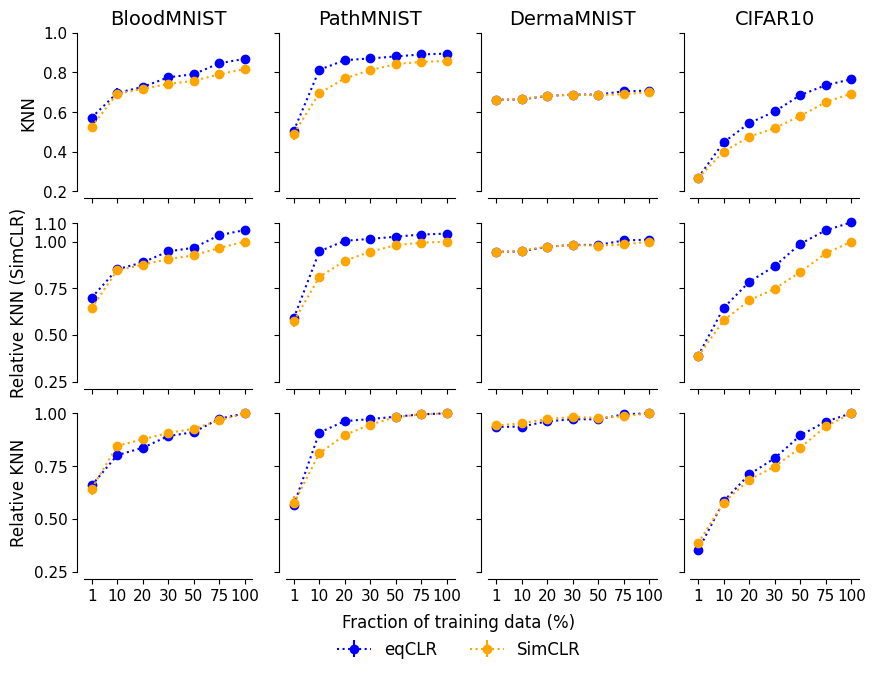

In [74]:
fig, ax = plt.subplots(3, 4, figsize=(10,7), sharex=True, sharey='row')

fontsize = 12

dataset_names = ['BloodMNIST', 'PathMNIST', 'DermaMNIST', 'CIFAR10']

for i, name in enumerate(dataset_names):
    # Plot eqCLR
    ax[0, i].errorbar(
        x=range(len(fractions)),
        y=eqclr_means[i],
        yerr=eqclr_stds[i],
        fmt='o',
        linestyle=':',
        color='blue',
        label='eqCLR',
        clip_on=False
    )

    # Plot SimCLR
    ax[0, i].errorbar(
        x=range(len(fractions)),
        y=simclr_means[i],
        yerr=simclr_stds[i],
        fmt='o',
        linestyle=':',
        color='orange',
        label='SimCLR',
        clip_on=False
    )

    ax[0, i].set_xticks(range(len(fractions)))
    ax[0, i].set_xticklabels(x_labels)
    ax[0, 0].set_ylabel('KNN', fontsize=12)
    ax[0, i].set_title(name, fontsize=14)

    # relative performance (to SimCLR)
    ax[1, i].errorbar(
        x=range(len(fractions)),
        y=np.array(eqclr_means[i]) / max(simclr_means[i]),
        yerr=eqclr_stds[i],
        fmt='o',
        linestyle=':',
        color='blue',
        label='eqCLR',
        clip_on=False
    )

    ax[1, i].errorbar(
        x=range(len(fractions)),
        y=np.array(simclr_means[i]) / max(simclr_means[i]),
        yerr=simclr_stds[i],
        fmt='o',
        linestyle=':',
        color='orange',
        label='SimCLR',
        clip_on=False
    )

    ax[1, i].set_xticks(range(len(fractions)))
    ax[1, i].set_xticklabels(x_labels)
    #ax[1, i].set_xlabel('Fraction of training data (%)', fontsize=12)
    ax[1, 0].set_ylabel('Relative KNN (SimCLR)', fontsize=12)

    # relative performance
    ax[2, i].errorbar(
        x=range(len(fractions)),
        y=np.array(eqclr_means[i]) / max(eqclr_means[i]),
        yerr=eqclr_stds[i],
        fmt='o',
        linestyle=':',
        color='blue',
        label='eqCLR',
        clip_on=False
    )

    ax[2, i].errorbar(
        x=range(len(fractions)),
        y=np.array(simclr_means[i]) / max(simclr_means[i]),
        yerr=simclr_stds[i],
        fmt='o',
        linestyle=':',
        color='orange',
        label='SimCLR',
        clip_on=False
    )

    ax[2, i].set_xticks(range(len(fractions)))
    ax[2, i].set_xticklabels(x_labels)
    #ax[2, i].set_xlabel('Fraction of training data (%)', fontsize=12)
    ax[2, 0].set_ylabel('Relative KNN', fontsize=12)

ax[0,0].set_ylim(0.2, 1)
ax[1,0].set_ylim(0.25, 1.1)
ax[1,0].set_yticks([0.25, 0.5, 0.75, 1.0, 1.1])
ax[2,0].set_ylim(0.25, 1)
ax[2,0].set_yticks([0.25, 0.5, 0.75, 1.0])
#ax[0,3].legend(frameon=False, loc='upper right', bbox_to_anchor=(1.8, 1.0), fontsize=fontsize)

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['bottom'].set_position(('outward', 5))
    a.spines['left'].set_position(('outward', 5))
    a.tick_params(axis='both', which='major', labelsize=fontsize-1)

fig.text(0.5, 0.03, 'Fraction of training data (%)', ha='center', fontsize=fontsize)
handles, labels = ax[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,              # one row with 2 entries
    frameon=False,
    fontsize=fontsize,
    bbox_to_anchor=(0.5, -0.035)  # adjust vertical position
)
